In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../Heart_Disease_Dataset/HeartDiseaseTrain-Test.csv')
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [3]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [4]:
df.describe()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


### Handling Null Values ###

In [5]:
# checking for nul values
df.isnull().sum()

# Check actual column names
print(df.columns.tolist())

['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate', 'exercise_induced_angina', 'oldpeak', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia', 'target']


In [6]:
# Rename misspelled column if it exists
if 'cholestoral' in df.columns:
    df.rename(columns={'cholestoral': 'cholesterol'}, inplace=True)


There are no null values in this dataset

In [7]:
# grouping together the numerical 
numerical_cols = ['age', 'resting_blood_pressure', 'cholesterol', 'max_heart_rate', 'oldpeak']
numerical_cols = [col for col in numerical_cols if col in df.columns]

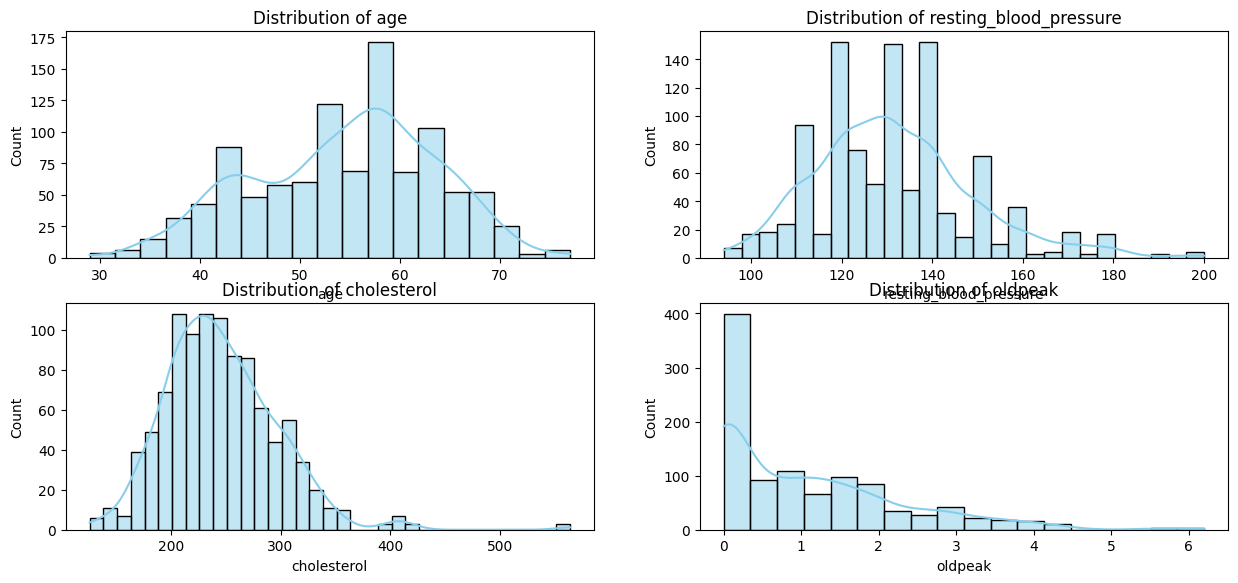

In [8]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

In [9]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

C:\Users\kenol\AppData\Local\Temp\ipykernel_11776\624130630.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
C:\Users\kenol\AppData\Local\Temp\ipykernel_11776\624130630.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
C:\Users\kenol\AppData\Local\Temp\ipykernel_11776\624130630.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
C:\Users\kenol\AppData\Local\Temp\ipykernel_11776\624130630.py:4: FutureWarning: 

Passing `palette`

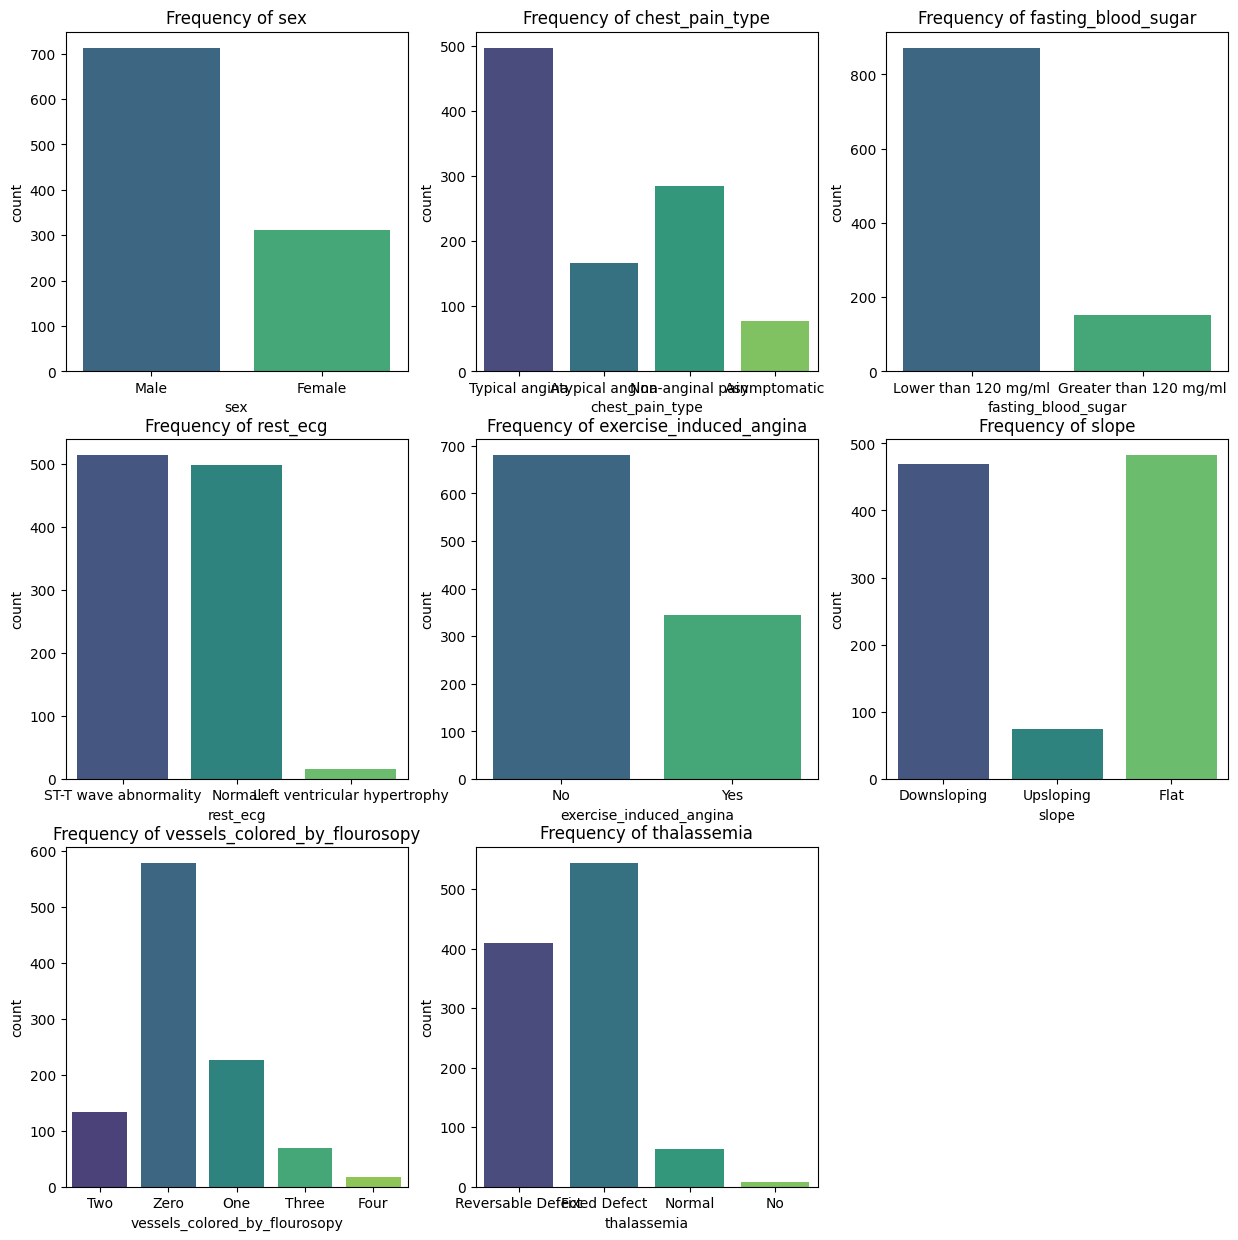

In [10]:
plt.figure(figsize=(15, 15))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Frequency of {col}')

The medical values for blood vessels coloured by fluroscopy is 0-3 but there is a 4 variable. I plan to treat this as null and remove it.

C:\Users\kenol\AppData\Local\Temp\ipykernel_11776\2888143196.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


Text(0.5, 1.0, 'Distribution of Heart Disease')

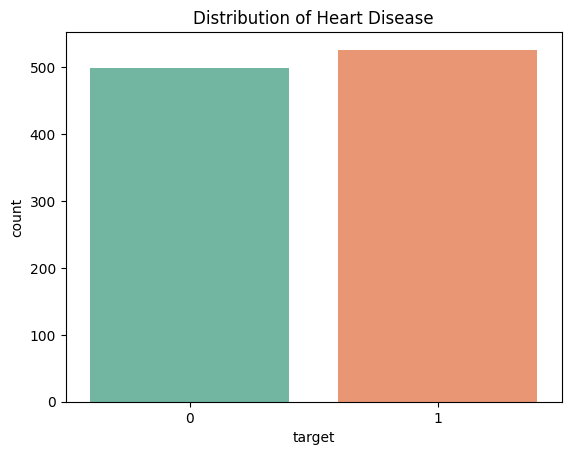

In [11]:
# checking the distribution on the target variable
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Distribution of Heart Disease')

The target variable is balanced

## Bivariate Analysis ##

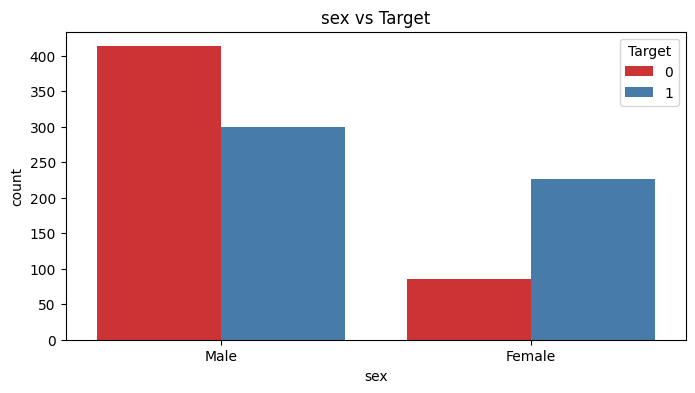

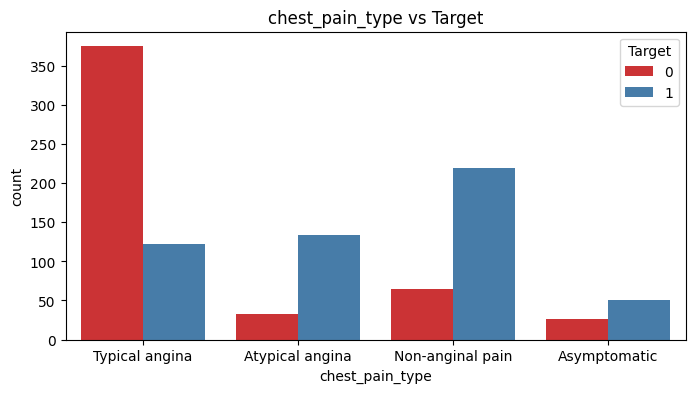

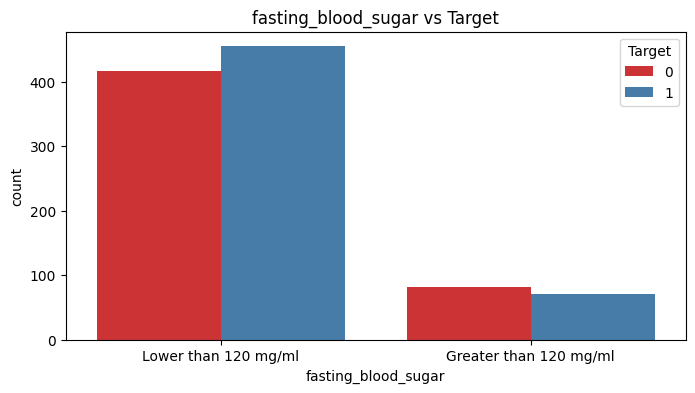

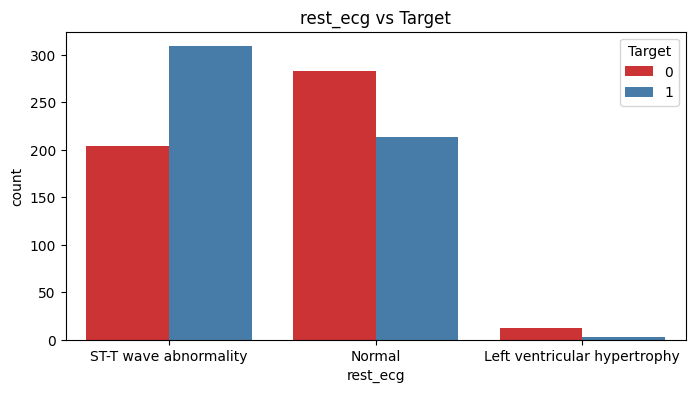

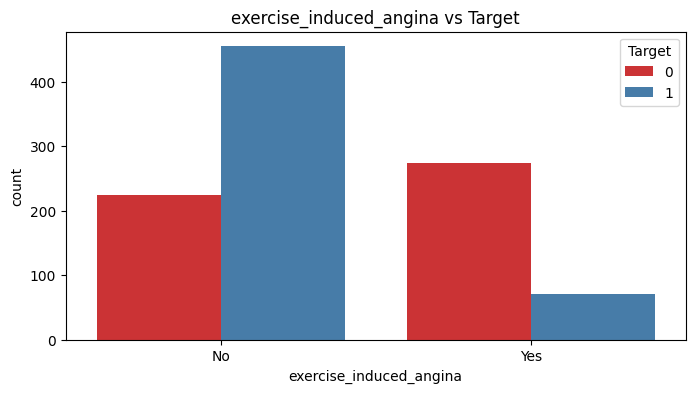

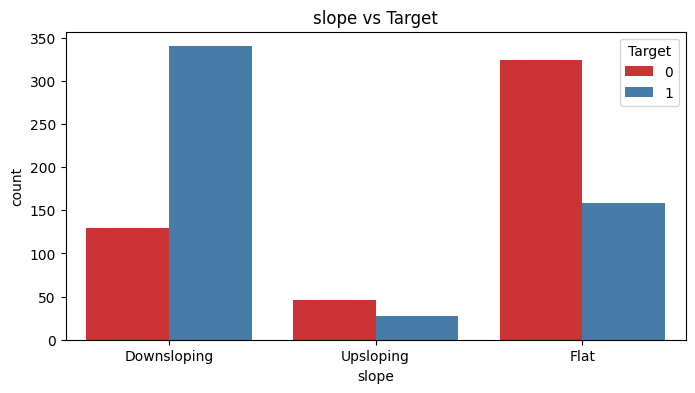

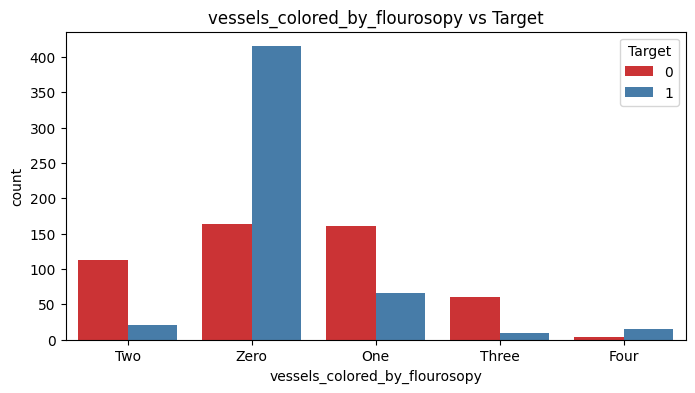

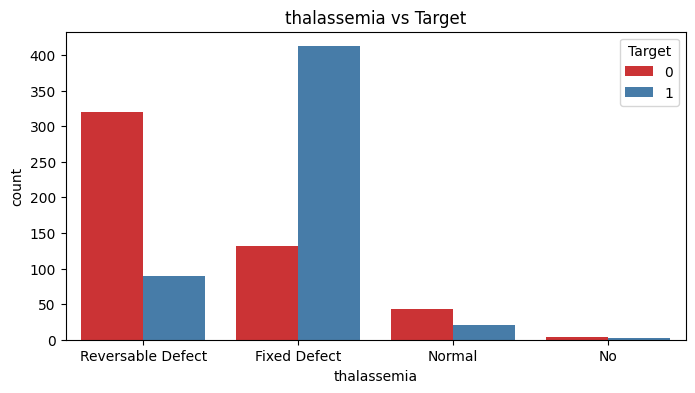

In [12]:
# comparing categorical features with the target variable
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='target', palette='Set1')
    plt.title(f'{col} vs Target')
    plt.legend(title='Target', loc='upper right')

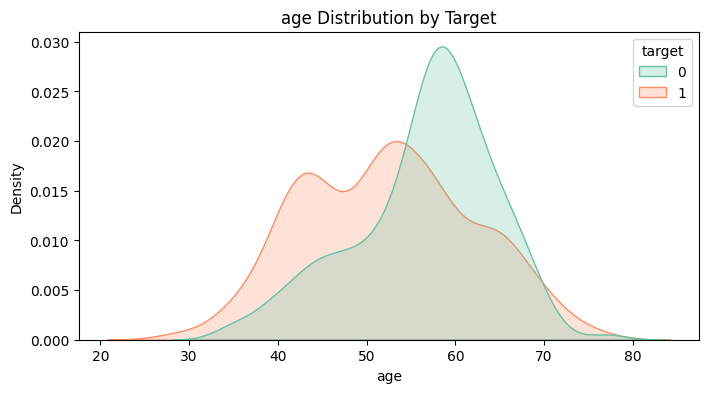

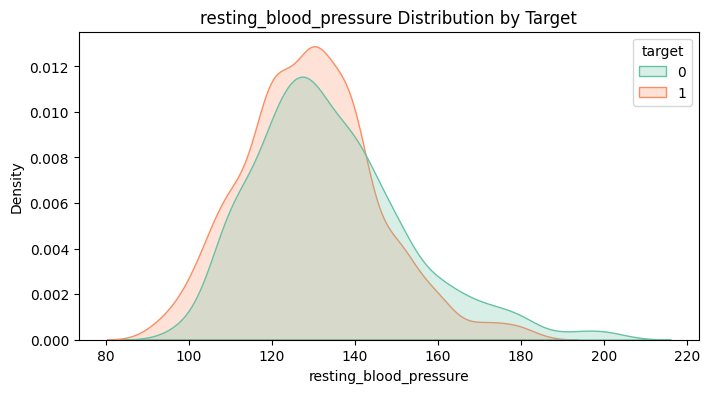

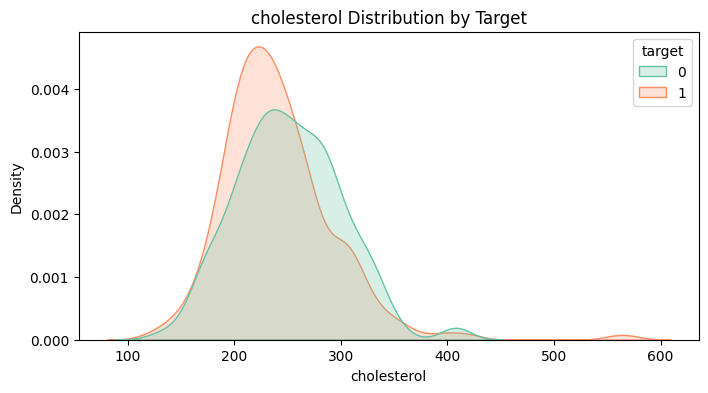

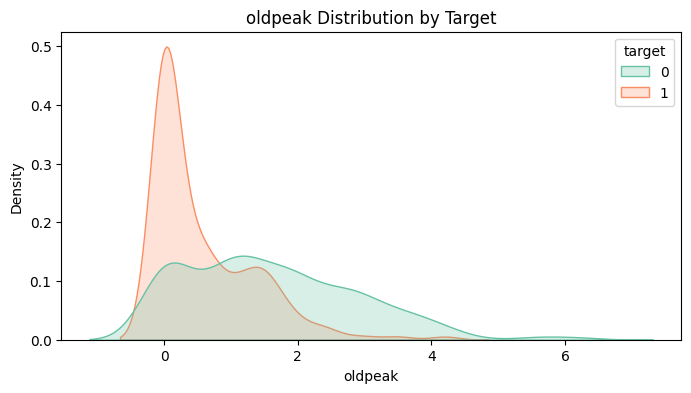

In [13]:
# comparing numerical features with the target variable
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=col, hue='target', fill=True, palette='Set2')
    plt.title(f'{col} Distribution by Target')

## Multivarate Analysis ##

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features and Target')

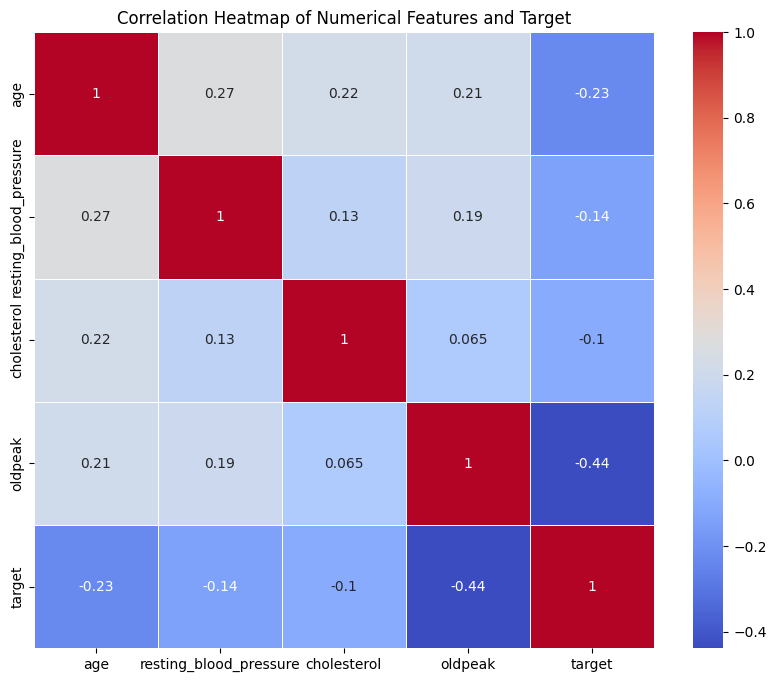

In [14]:
# correlation heatmap for numerical features and target variable

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols + ['target']].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features and Target')

old peak is the one with the highest correlation with heart disease. Correlation is negative.

c:\Users\kenol\Documents\Heart_Disease_Prediction_App\heartdisease\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Text(0.5, 1.0, 'Fasting Blood Sugar vs Resting Blood Pressure')

c:\Users\kenol\Documents\Heart_Disease_Prediction_App\heartdisease\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


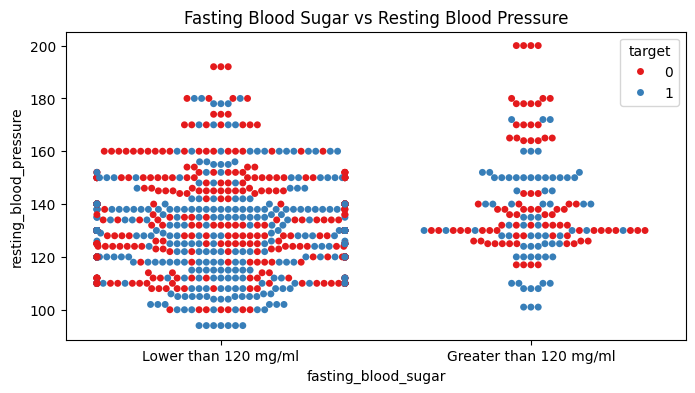

In [15]:
# comparing fasting blood sugar, resting blood pressure and target variable
plt.figure(figsize=(8, 4))
sns.swarmplot(data=df, x='fasting_blood_sugar', y='resting_blood_pressure', hue='target', palette='Set1')
plt.title('Fasting Blood Sugar vs Resting Blood Pressure')

## Preprocessing ##

In [16]:
# Treating the four in vessels_coloured_by_fluoroscopy and no in thalassemia as missing values. replace with mode
for col in ['vessels_colored_by_flourosopy', 'thalassemia']:
        mode_value = df[col].mode()[0]
        df[col] = df[col].replace({'Four': mode_value, 'No': mode_value})

In [17]:
# confirming the replacement
print(df['vessels_colored_by_flourosopy'].value_counts())
print(df['thalassemia'].value_counts())

vessels_colored_by_flourosopy
Zero     596
One      226
Two      134
Three     69
Name: count, dtype: int64
thalassemia
Fixed Defect         551
Reversable Defect    410
Normal                64
Name: count, dtype: int64


## One-Hot Encoding ##

In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,resting_blood_pressure,cholesterol,Max_heart_rate,oldpeak,target,sex_Male,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,...,rest_ecg_Normal,rest_ecg_ST-T wave abnormality,exercise_induced_angina_Yes,slope_Flat,slope_Upsloping,vessels_colored_by_flourosopy_Three,vessels_colored_by_flourosopy_Two,vessels_colored_by_flourosopy_Zero,thalassemia_Normal,thalassemia_Reversable Defect
0,52,125,212,168,1.0,0,True,False,False,True,...,False,True,False,False,False,False,True,False,False,True
1,53,140,203,155,3.1,0,True,False,False,True,...,True,False,True,False,True,False,False,True,False,True
2,70,145,174,125,2.6,0,True,False,False,True,...,False,True,True,False,True,False,False,True,False,True
3,61,148,203,161,0.0,0,True,False,False,True,...,False,True,False,False,False,False,False,False,False,True
4,62,138,294,106,1.9,0,False,False,False,True,...,False,True,False,True,False,True,False,False,False,False


In [20]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
numerical_cols = ['age', 'resting_blood_pressure', 'cholesterol', 'Max_heart_rate', 'oldpeak']

df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [21]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']   
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 

# Initialize each model
logistic_model = LogisticRegression()
random_forest_model = RandomForestClassifier()
svm_model = SVC()

In [23]:
# Looping through each model, fitting it, and evaluating its performance
models = {
    'Logistic Regression': logistic_model,
    'Random Forest': random_forest_model,
    'Support Vector Machine': svm_model
}  

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'--- {name} ---')
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}\n')

--- Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.75      0.80       102
           1       0.78      0.89      0.83       103

    accuracy                           0.82       205
   macro avg       0.83      0.82      0.82       205
weighted avg       0.83      0.82      0.82       205

Confusion Matrix:
[[76 26]
 [11 92]]
Accuracy: 0.8195

--- Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

Confusion Matrix:
[[102   0]
 [  3 100]]
Accuracy: 0.9854

--- Support Vector Machine ---
Classification Report:
              precision    recall  f1-score   support

           0       0.92    

Text(0.5, 1.0, 'Confusion Matrix for Random Forest')

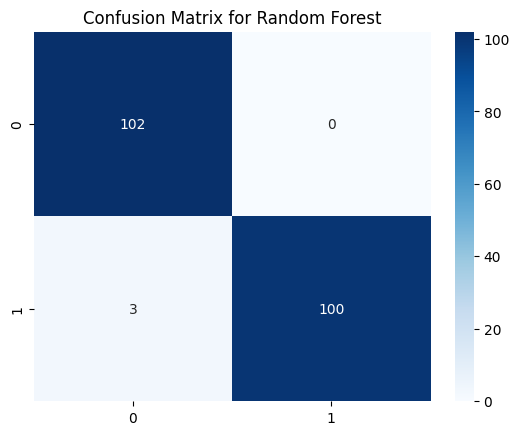

In [24]:
# Visualizing winning model performance with confusion matrix and classification report
best_model = random_forest_model
y_pred_best = best_model.predict(X_test)

hdm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(hdm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Random Forest')


In [25]:
#saving the model and scaler for deployment
import joblib
joblib.dump(best_model, 'heart_disease_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
